# 🦋 Smart Insect Identifier — Training Notebook (Colab + Drive Checkpoint)

## 0. Mount Google Drive & Setup GPU

In [ ]:
# LANGKAH 1: Mount Google Drive dulu
from google.colab import drive
drive.mount('/content/drive')

# Folder kerja di Drive — semua checkpoint & model disimpan di sini
import os
DRIVE_DIR = '/content/drive/MyDrive/SmartInsect_v2'  # folder baru
os.makedirs(DRIVE_DIR, exist_ok=True)
os.makedirs(f'{DRIVE_DIR}/artifacts', exist_ok=True)
os.makedirs(f'{DRIVE_DIR}/checkpoints', exist_ok=True)

print(f'Drive mounted!')
print(f'Semua file disimpan di: {DRIVE_DIR}')

Mounted at /content/drive
Drive mounted!
Semua file disimpan di: /content/drive/MyDrive/SmartInsect_v2


In [ ]:
# Cek GPU
import torch, sys
print('PyTorch:', torch.__version__)
print('CUDA:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('⚠️  Belum ada GPU! Runtime → Change runtime type → GPU T4')

PyTorch: 2.11.0+cu128
CUDA: True
GPU: Tesla T4


In [ ]:
!pip install timm -q
print('Install OK!')

Install OK!


## 1. Download Dataset (Skip kalau sudah ada di Drive)

In [ ]:
import os

DATASET_PATH = f'{DRIVE_DIR}/insects'

# Cek apakah dataset sudah ada di Drive
if os.path.exists(DATASET_PATH) and len(os.listdir(DATASET_PATH)) > 0:
    print(f'✅ Dataset sudah ada di Drive: {DATASET_PATH}')
    print('Skip download!')
else:
    print('Dataset belum ada, download sekarang...')
    print('Upload kaggle.json:')
    from google.colab import files
    uploaded = files.upload()  # upload kaggle.json di sini

    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

    print('Downloading dataset ke Drive (~2GB, tunggu ya)...')
    !kaggle datasets download -d baxtiyorbotiraliyev/insects -p /content/tmp_insects --unzip

    print('Memindahkan ke Drive...')
    !cp -r /content/tmp_insects/* {DATASET_PATH}/
    !rm -rf /content/tmp_insects
    print(f'✅ Dataset tersimpan di Drive!')

# Tampilkan struktur
for root, dirs, files_list in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, '').count(os.sep)
    if level < 3:
        print('  ' * level + os.path.basename(root) + '/')

Dataset belum ada, download sekarang...
Upload kaggle.json:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/baxtiyorbotiraliyev/insects
License(s): apache-2.0
100% 5.08G/5.08G [04:37<00:00, 19.7MB/s]

Memindahkan ke Drive...
✅ Dataset tersimpan di Drive!
insects/
  test/
    adristyrannus/
    aleurocanthus spiniferus/
    alfalfa plant bug/
    alfalfa seed chalcid/
    alfalfa weevil/
    ampelophaga/
    ant/
    aphids/
    apolygus lucorum/
    armyworm/
    asiatic rice borer/
    bactrocera tsuneonis/
    bee/
    beet fly/
    beetle/
    black cutworm/
    blister beetle/
    bollworm/
    brevipoalpus lewisi McGregor/
    brown plant hopper/
    butterfly/
    catterpillar/
    cerodonta denticornis/
    ceroplastes rubens/
    chayon/
    chlumetia transversa/
    chrysomphalus aonidum/
    cicadella viridis/
    cicadellidae/
    corn borer/
    dacus dorsalis(Hendel)/
    dasineura sp/
    deporaus marginatus Pascoe/
    dragonfly/
    earthworm/
    earwig/
    erythroneura apicalis/
    fall armywor

## 2. Import & Konfigurasi

In [ ]:
import json, time, copy, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
import timm
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Path
BASE_DATASET = DATASET_PATH
OUTPUT_DIR   = Path(f'{DRIVE_DIR}/artifacts')
CKPT_DIR     = Path(f'{DRIVE_DIR}/checkpoints')
CKPT_FILE    = CKPT_DIR / 'latest_checkpoint.pt'

# Hyperparameter
IMG_SIZE   = 224
BATCH_SIZE = 16
NUM_EPOCHS = 30
LR         = 1e-4
PATIENCE   = 5
MODEL_NAME = 'efficientnet_b3'

print(f'Device: {DEVICE}')
print(f'Output : {OUTPUT_DIR}')
print(f'Checkpoint: {CKPT_FILE}')

Device: cuda
Output : /content/drive/MyDrive/SmartInsect_v2/artifacts
Checkpoint: /content/drive/MyDrive/SmartInsect_v2/checkpoints/latest_checkpoint.pt


## 3. Deteksi Struktur Dataset & Eksplorasi

USE_SPLIT: True
TRAIN_DIR: /content/drive/MyDrive/SmartInsect_v2/insects/train

Kelas (118): ['adristyrannus', 'aleurocanthus spiniferus', 'alfalfa plant bug', 'alfalfa seed chalcid', 'alfalfa weevil', 'ampelophaga', 'ant', 'aphids', 'apolygus lucorum', 'armyworm', 'asiatic rice borer', 'bactrocera tsuneonis', 'bee', 'beet fly', 'beetle', 'black cutworm', 'blister beetle', 'bollworm', 'brevipoalpus lewisi McGregor', 'brown plant hopper', 'butterfly', 'catterpillar', 'cerodonta denticornis', 'ceroplastes rubens', 'chayon', 'chlumetia transversa', 'chrysomphalus aonidum', 'cicadella viridis', 'cicadellidae', 'corn borer', 'dacus dorsalis(Hendel)', 'dasineura sp', 'deporaus marginatus Pascoe', 'dragonfly', 'earthworm', 'earwig', 'erythroneura apicalis', 'fall armyworm', 'flax budworm', 'flea beetle', 'fly', 'grain spreader thrips', 'grasshopper', 'grub', 'icerya purchasi Maskell', 'kolorado', 'ladybug', 'large cutworm', 'lawana imitata Melichar', 'leaf beetle', 'legume blister beetle', 'l

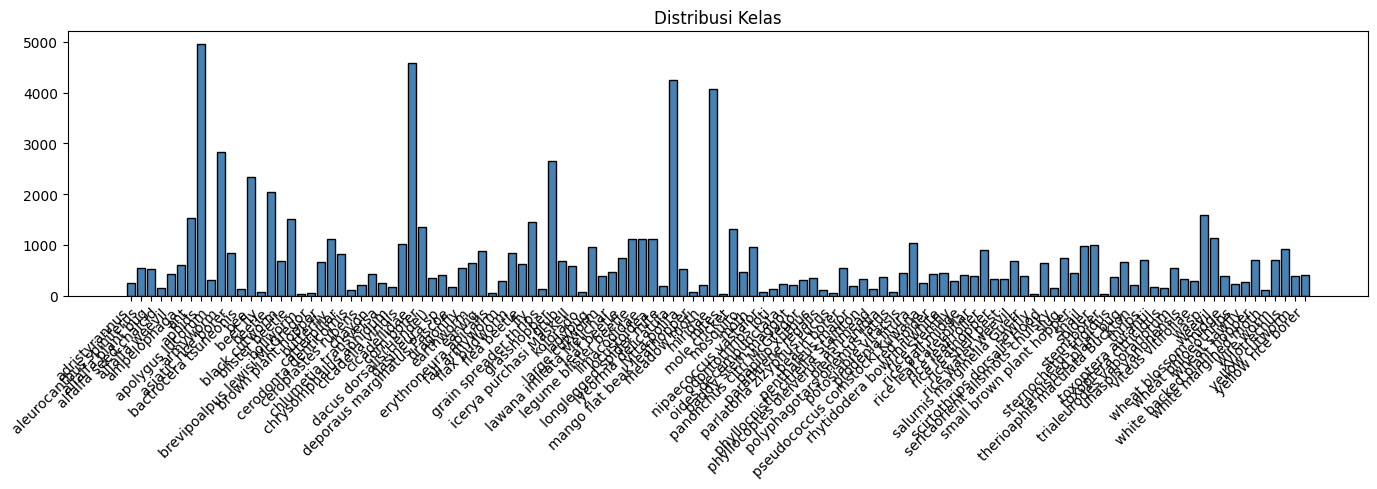

In [ ]:
base = Path(BASE_DATASET)

# Deteksi otomatis apakah ada folder train/val/test
if (base / 'dataset' / 'train').exists():
    TRAIN_DIR = base / 'dataset' / 'train'
    VAL_DIR   = base / 'dataset' / 'val'
    TEST_DIR  = base / 'dataset' / 'test' if (base / 'dataset' / 'test').exists() else VAL_DIR
    USE_SPLIT = True
elif (base / 'train').exists():
    TRAIN_DIR = base / 'train'
    VAL_DIR   = base / 'val'
    TEST_DIR  = base / 'test' if (base / 'test').exists() else VAL_DIR
    USE_SPLIT = True
else:
    # Cari folder yang isinya subfolder kelas
    def find_root(p):
        for root, dirs, _ in os.walk(str(p)):
            rp = Path(root)
            subdirs = [d for d in rp.iterdir() if d.is_dir()]
            if subdirs:
                imgs = list(subdirs[0].glob('*.jpg')) + list(subdirs[0].glob('*.png'))
                if imgs: return rp
        return p
    TRAIN_DIR = find_root(base)
    VAL_DIR = TEST_DIR = TRAIN_DIR
    USE_SPLIT = False

print(f'USE_SPLIT: {USE_SPLIT}')
print(f'TRAIN_DIR: {TRAIN_DIR}')

class_dirs  = sorted([d for d in TRAIN_DIR.iterdir() if d.is_dir()])
class_names = [d.name for d in class_dirs]
NUM_CLASSES = len(class_names)
class_to_idx = {c: i for i, c in enumerate(class_names)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

class_counts = {}
for d in class_dirs:
    imgs = list(d.rglob('*.jpg')) + list(d.rglob('*.png')) + list(d.rglob('*.jpeg'))
    class_counts[d.name] = len(imgs)

print(f'\nKelas ({NUM_CLASSES}): {class_names}')
print(f'Total gambar training: {sum(class_counts.values())}')

plt.figure(figsize=(14, 5))
plt.bar(class_counts.keys(), class_counts.values(), color='steelblue', edgecolor='black')
plt.xticks(rotation=45, ha='right'); plt.title('Distribusi Kelas')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.png', dpi=150)
plt.show()

## 4. Dataset & DataLoader

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE+32, IMG_SIZE+32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.2),
    transforms.RandomRotation(30),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.1),
    transforms.RandomAffine(0, translate=(0.1,0.1), scale=(0.9,1.1)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(0.2),
])
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class InsectDataset(Dataset):
    def __init__(self, root_dir, transform=None, class_to_idx=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.classes = sorted([d.name for d in self.root_dir.iterdir() if d.is_dir()])
        self.class_to_idx = class_to_idx or {c:i for i,c in enumerate(self.classes)}
        self.samples = []
        valid_exts = {'.jpg','.jpeg','.png','.bmp'}
        for cls in self.classes:
            for f in (self.root_dir/cls).iterdir():
                if f.suffix.lower() in valid_exts:
                    self.samples.append((f, self.class_to_idx[cls]))
        print(f'{self.root_dir.name}: {len(self.samples)} samples')

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try: img = Image.open(path).convert('RGB')
        except: img = Image.new('RGB',(IMG_SIZE,IMG_SIZE),(0,0,0))
        if self.transform: img = self.transform(img)
        return img, label

if USE_SPLIT:
    train_ds = InsectDataset(TRAIN_DIR, train_transform, class_to_idx)
    val_ds   = InsectDataset(VAL_DIR,   val_transform,   class_to_idx)
    test_ds  = InsectDataset(TEST_DIR,  val_transform,   class_to_idx)
else:
    full_ds = InsectDataset(TRAIN_DIR, None, class_to_idx)
    N = len(full_ds)
    n_test = int(N*0.15); n_val = int(N*0.15); n_train = N-n_test-n_val
    tr_idx, vl_idx, te_idx = random_split(range(N),[n_train,n_val,n_test],
                                           generator=torch.Generator().manual_seed(SEED))
    class SubDS(Dataset):
        def __init__(self,ds,idx,tf): self.ds=ds; self.idx=list(idx); self.tf=tf
        def __len__(self): return len(self.idx)
        def __getitem__(self,i):
            p,l=self.ds.samples[self.idx[i]]
            try: img=Image.open(p).convert('RGB')
            except: img=Image.new('RGB',(IMG_SIZE,IMG_SIZE),(0,0,0))
            if self.tf: img=self.tf(img)
            return img,l
    train_ds=SubDS(full_ds,tr_idx,train_transform)
    val_ds  =SubDS(full_ds,vl_idx,val_transform)
    test_ds =SubDS(full_ds,te_idx,val_transform)

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'Train:{len(train_ds)} Val:{len(val_ds)} Test:{len(test_ds)}')

train: 90115 samples
val: 11215 samples
test: 11363 samples
Train:90115 Val:11215 Test:11363


## 5. Model & Checkpoint System

In [ ]:
def build_model(num_classes, pretrained=True):
    return timm.create_model(MODEL_NAME, pretrained=pretrained, num_classes=num_classes)

def save_checkpoint(model, optimizer, scheduler, epoch, history, phase, best_val_acc, path):
    """Simpan semua state ke Drive."""
    torch.save({
        'epoch'        : epoch,
        'phase'        : phase,
        'model_state'  : model.state_dict(),
        'optimizer'    : optimizer.state_dict(),
        'scheduler'    : scheduler.state_dict() if scheduler else None,
        'history'      : history,
        'best_val_acc' : best_val_acc,
    }, path)
    print(f'  💾 Checkpoint saved → Drive (epoch {epoch}, phase {phase})')

def load_checkpoint(path, model, optimizer, scheduler):
    """Load checkpoint dari Drive."""
    ckpt = torch.load(path, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer'])
    if scheduler and ckpt['scheduler']:
        scheduler.load_state_dict(ckpt['scheduler'])
    print(f'✅ Checkpoint loaded! Lanjut dari epoch {ckpt["epoch"]+1}, phase {ckpt["phase"]}')
    return ckpt['epoch'], ckpt['phase'], ckpt['history'], ckpt['best_val_acc']

# Buat model
model = build_model(NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
scaler    = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None

print(f'Model: {MODEL_NAME} | Classes: {NUM_CLASSES}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Model: efficientnet_b3 | Classes: 118


/tmp/ipykernel_2068/248754427.py:32: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None


## 6. Training — Auto Resume dari Checkpoint

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    loss_sum, correct, total = 0, 0, 0
    for imgs, labels in tqdm(loader, desc='Train', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        if scaler:
            with torch.cuda.amp.autocast():
                out = model(imgs); loss = criterion(out, labels)
            scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        else:
            out = model(imgs); loss = criterion(out, labels)
            loss.backward(); optimizer.step()
        loss_sum += loss.item()*imgs.size(0)
        correct  += out.max(1)[1].eq(labels).sum().item()
        total    += imgs.size(0)
    return loss_sum/total, correct/total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    loss_sum, correct, total = 0, 0, 0
    for imgs, labels in tqdm(loader, desc='Eval', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out = model(imgs); loss = criterion(out, labels)
        loss_sum += loss.item()*imgs.size(0)
        correct  += out.max(1)[1].eq(labels).sum().item()
        total    += imgs.size(0)
    return loss_sum/total, correct/total

# ── Cek apakah ada checkpoint di Drive ────────────────────────
history      = {'train_loss':[],'train_acc':[],'val_loss':[],'val_acc':[]}
best_val_acc = 0.0
start_epoch  = 1
current_phase = 1
patience_counter = 0
best_val_loss = float('inf')
best_model_state = None

if CKPT_FILE.exists():
    print('🔄 Checkpoint ditemukan di Drive! Mau lanjut dari sana?')
    print('Jawab: jalankan cell berikutnya untuk RESUME, atau skip untuk mulai ulang')
else:
    print('Tidak ada checkpoint — mulai training dari awal')
    # Freeze backbone untuk phase 1
    for name, param in model.named_parameters():
        if 'classifier' not in name and 'head' not in name:
            param.requires_grad = False
    print('Phase 1: backbone frozen')

Tidak ada checkpoint — mulai training dari awal
Phase 1: backbone frozen


In [ ]:
# RESUME dari checkpoint (jalankan cell ini kalau mau lanjut)
if CKPT_FILE.exists():
    start_epoch, current_phase, history, best_val_acc = load_checkpoint(
        CKPT_FILE, model, optimizer, scheduler
    )
    start_epoch += 1  # lanjut dari epoch berikutnya
    best_val_loss = min(history['val_loss']) if history['val_loss'] else float('inf')
    best_model_state = copy.deepcopy(model.state_dict())

    print(f'\nStatus training:')
    print(f'  Sudah selesai : {len(history["train_loss"])} epoch')
    print(f'  Phase saat ini: {current_phase}')
    print(f'  Best val acc  : {best_val_acc*100:.2f}%')
    print(f'  Lanjut dari   : epoch {start_epoch}')
else:
    print('Mulai dari awal (tidak ada checkpoint)')

Mulai dari awal (tidak ada checkpoint)


In [ ]:
# ── MAIN TRAINING LOOP ─────────────────────────────────────────
WARMUP_EPOCHS = 5

print('='*55)
print(f'Mulai training dari epoch {start_epoch}')
print('='*55)

for epoch in range(start_epoch, NUM_EPOCHS + WARMUP_EPOCHS + 1):

    # Switch ke phase 2 setelah warmup selesai
    if epoch == WARMUP_EPOCHS + 1 and current_phase == 1:
        current_phase = 2
        for param in model.parameters():
            param.requires_grad = True
        # Reset optimizer dengan LR lebih kecil
        optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
        print('\n🔓 PHASE 2: Semua layer di-unfreeze, fine-tuning dimulai!')

    # Gunakan LR warmup untuk phase 1
    if current_phase == 1:
        for pg in optimizer.param_groups:
            pg['lr'] = 1e-3

    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion)
    if current_phase == 2: scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    phase_label = 'P1-WarmUp' if current_phase == 1 else 'P2-FineTune'
    print(f'[{phase_label}] Epoch {epoch:02d} | '
          f'Train {tr_loss:.4f}/{tr_acc:.4f} | '
          f'Val {vl_loss:.4f}/{vl_acc:.4f} | '
          f'{time.time()-t0:.1f}s')

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_model_state = copy.deepcopy(model.state_dict())
        print(f'  ★ New best val acc: {best_val_acc*100:.2f}%')

    # Simpan checkpoint ke Drive setiap epoch
    save_checkpoint(model, optimizer, scheduler, epoch, history, current_phase, best_val_acc, CKPT_FILE)

    # Early stopping (hanya phase 2)
    if current_phase == 2:
        if vl_loss < best_val_loss - 1e-4:
            best_val_loss = vl_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f'\n⚡ Early stopping at epoch {epoch}!')
                break

# Load bobot terbaik
if best_model_state:
    model.load_state_dict(best_model_state)
print(f'\n✅ Training selesai! Best Val Acc: {best_val_acc*100:.2f}%')

Mulai training dari epoch 1


Train:   0%|          | 0/5633 [00:00<?, ?it/s]

/tmp/ipykernel_2068/2043334356.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Eval:   0%|          | 0/701 [00:00<?, ?it/s]

[P1-WarmUp] Epoch 01 | Train 2.6559/0.4797 | Val 2.2956/0.5757 | 1707.5s
  ★ New best val acc: 57.57%
  💾 Checkpoint saved → Drive (epoch 1, phase 1)


...

Eval:   0%|          | 0/701 [00:00<?, ?it/s]

[P2-FineTune] Epoch 06 | Train 1.7450/0.7297 | Val 1.6792/0.7623 | 1847.2s
  ★ New best val acc: 76.23%
  💾 Checkpoint saved → Drive (epoch 6, phase 2)


Train:   0%|          | 0/5633 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


KeyboardInterrupt: 

## 7. Learning Curves

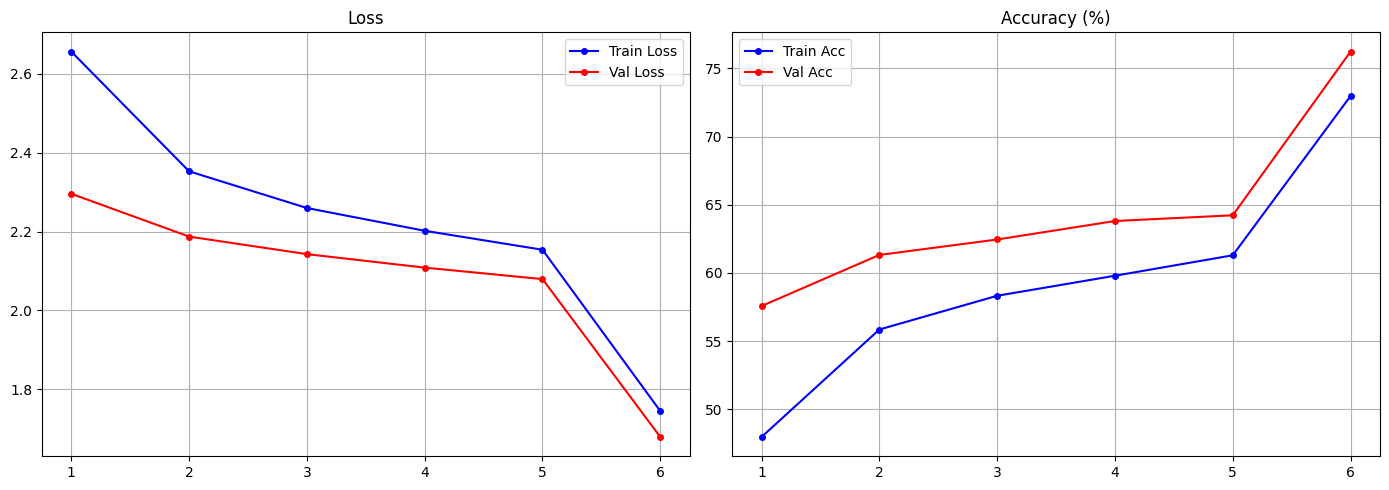

In [ ]:
ep = range(1, len(history['train_loss'])+1)
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(14,5))
ax1.plot(ep, history['train_loss'],'b-o',markersize=4,label='Train Loss')
ax1.plot(ep, history['val_loss'],  'r-o',markersize=4,label='Val Loss')
ax1.set_title('Loss'); ax1.legend(); ax1.grid(0.3)
ax2.plot(ep,[a*100 for a in history['train_acc']],'b-o',markersize=4,label='Train Acc')
ax2.plot(ep,[a*100 for a in history['val_acc']],  'r-o',markersize=4,label='Val Acc')
ax2.set_title('Accuracy (%)'); ax2.legend(); ax2.grid(0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'learning_curves.png',dpi=150)
plt.show()

## 8. Evaluasi Test Set

In [ ]:
@torch.no_grad()
def get_preds(model, loader):
    model.eval()
    preds, labels, probs = [], [], []
    for imgs, lbls in tqdm(loader, desc='Testing'):
        imgs = imgs.to(DEVICE)
        p = torch.softmax(model(imgs),1)
        preds.extend(p.max(1)[1].cpu().numpy())
        labels.extend(lbls.numpy())
        probs.extend(p.cpu().numpy())
    return np.array(preds), np.array(labels), np.array(probs)

y_pred, y_true, y_probs = get_preds(model, test_loader)
test_acc = accuracy_score(y_true, y_pred)
print(f'\n✅ Test Accuracy: {test_acc*100:.2f}%')
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

Testing:   0%|          | 0/711 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



✅ Test Accuracy: 77.05%
                                 precision    recall  f1-score   support

                  adristyrannus     0.7778    0.6562    0.7119        32
       aleurocanthus spiniferus     0.8235    0.8116    0.8175        69
              alfalfa plant bug     0.5532    0.3881    0.4561        67
           alfalfa seed chalcid     0.5714    0.2105    0.3077        19
                 alfalfa weevil     0.5745    0.5094    0.5400        53
                    ampelophaga     0.7439    0.7922    0.7673        77
                            ant     0.8704    0.9741    0.9193       193
                         aphids     0.7830    0.8613    0.8203       620
               apolygus lucorum     0.5000    0.4103    0.4507        39
                       armyworm     0.5629    0.6969    0.6228       353
             asiatic rice borer     0.4286    0.5660    0.4878       106
           bactrocera tsuneonis     0.8750    0.3889    0.5385        18
                         

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(max(10,NUM_CLASSES), max(8,NUM_CLASSES-2)))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix — Test Acc: {test_acc*100:.2f}%')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig(OUTPUT_DIR/'confusion_matrix.png',dpi=150,bbox_inches='tight')
plt.show()

## 9. Export Model ke Drive

In [ ]:
model.eval(); model_cpu = model.cpu()
dummy = torch.randn(1,3,IMG_SIZE,IMG_SIZE)

try:
    traced = torch.jit.trace(model_cpu, dummy)
    torch.jit.save(traced, str(OUTPUT_DIR/'insect_model.pt'))
    fmt = 'torchscript'
    print('✅ TorchScript model saved to Drive!')
except Exception as e:
    torch.save(model_cpu.state_dict(), str(OUTPUT_DIR/'insect_model_state.pt'))
    fmt = 'state_dict'
    print(f'State dict saved ({e})')

meta = {
    'model_name'   : MODEL_NAME,
    'num_classes'  : NUM_CLASSES,
    'img_size'     : IMG_SIZE,
    'class_names'  : class_names,
    'class_to_idx' : class_to_idx,
    'imagenet_mean': IMAGENET_MEAN,
    'imagenet_std' : IMAGENET_STD,
    'test_accuracy': float(test_acc),
    'model_format' : fmt,
}
with open(OUTPUT_DIR/'metadata.json','w') as f:
    json.dump(meta, f, indent=2)

print(f'\n✅ Semua file tersimpan di Google Drive: {OUTPUT_DIR}')
print(f'Test Accuracy: {test_acc*100:.2f}%')
for f in os.listdir(OUTPUT_DIR):
    size = os.path.getsize(OUTPUT_DIR/f)/(1024*1024)
    print(f'  📁 {f}  ({size:.1f} MB)')

✅ TorchScript model saved to Drive!

✅ Semua file tersimpan di Google Drive: /content/drive/MyDrive/SmartInsect_v2/artifacts
Test Accuracy: 77.05%
  📁 class_distribution.png  (0.4 MB)
  📁 learning_curves.png  (0.1 MB)
  📁 confusion_matrix.png  (2.9 MB)
  📁 insect_model.pt  (42.8 MB)
  📁 metadata.json  (0.0 MB)


## 10. Download dari Drive ke Laptop
*(Jalankan ini setelah training selesai)*

In [ ]:
from google.colab import files
import os

print('Downloading model files...')
for fname in os.listdir(OUTPUT_DIR):
    if fname.endswith('.pt') or fname.endswith('.json') or fname.endswith('.png'):
        files.download(str(OUTPUT_DIR/fname))
        print(f'  ✅ {fname}')

print('\nSelesai! Taruh insect_model.pt & metadata.json ke folder backend/artifacts/')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ class_distribution.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✅ insect_model.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ metadata.json

Selesai! Taruh insect_model.pt & metadata.json ke folder backend/artifacts/
